# Danskuddannelserne

This project uses the Danskuddannelse reports from 2011 to 2024 to be in /assets/. 

They can be downloaded from Integrationsbarometer (https://integrationsbarometer.dk/danskuddannelserne/arsrapporter)



## Data extraction

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

The data is available as PDF tables in yearly reports

In [ ]:
def extract_table(pdf_path, page_num,table_num=0):
    import pdfplumber
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_num - 1]  # Adjust for 0-based index
        tables = page.extract_tables()
        return tables[table_num]

In [189]:
def data_clean(year,page_num,table_num=0,drop_rows=2):
    df=pd.DataFrame(extract_table(f'./assets/Danskuddannelse{year}.pdf',page_num,table_num))
    for i in [0,2,3,5,6,8,9,11,12,13,14,15,17,18,20]:
        df = df.drop(i,axis=1)
    for i in range(0,drop_rows):
        df = df.drop(i)
    df.columns = ['Danskuddannelse','Tilmeldt','Gennemført','Bestået','Karatergennemsnit bestående','Karaktergennemsnit alle']
    df['år']=year
    df = df.set_index('Danskuddannelse')
    for col in ['Tilmeldt','Gennemført','Bestået']:
        df[col]=df[col].str.replace('.', '').astype(int)
    for col in ['Karatergennemsnit bestående','Karaktergennemsnit alle']:
        df[col]=df[col].str.replace(',', '.').astype(float)
    df = df.reset_index()
    df = df.set_index('år')
    return df

data_clean(2024,20)

,Danskuddannelse,Tilmeldt,Gennemført,Bestået,Karatergennemsnit bestående,Karaktergennemsnit alle
år,,,,,,
2024,Prøve i Dansk 1,597,576,543,6.4,6.1
2024,Prøve i Dansk 2,3274,3238,3136,7.3,7.1
2024,Prøve i Dansk 3,4201,4117,3767,6.7,6.2
2024,Studieprøven,332,316,270,7.3,6.7
2024,Alle kursister,8404,8247,7716,6.9,6.6


In [190]:
yearFiles = [data_clean(2018,18,1,1),data_clean(2019,18),data_clean(2020,20),
             data_clean(2021,20),data_clean(2022,20),data_clean(2023,20),data_clean(2024,20)]
df = pd.concat(yearFiles)
df.head()

,Danskuddannelse,Tilmeldt,Gennemført,Bestået,Karatergennemsnit bestående,Karaktergennemsnit alle
år,,,,,,
2018,Prøve i Dansk 1,2097,2070,1899,6.4,5.9
2018,Prøve i Dansk 2,5627,5592,5396,6.6,6.4
2018,Prøve i Dansk 3,4300,4147,3863,6.9,6.5
2018,Studieprøven,333,310,262,7.4,7.1
2018,Alle kursister,12357,12119,11420,6.7,6.4


(0.0, 12.0)

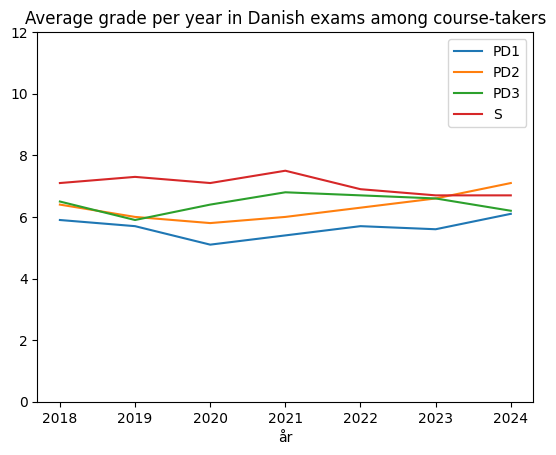

In [218]:
df1 = df[df['Danskuddannelse']=='Prøve i Dansk 1']
df2 = df[df['Danskuddannelse']=='Prøve i Dansk 2']
df3 = df[df['Danskuddannelse']=='Prøve i Dansk 3']
df4 = df[df['Danskuddannelse']=='Studieprøven']

df1['Karaktergennemsnit alle'].plot()
df2['Karaktergennemsnit alle'].plot()
df3['Karaktergennemsnit alle'].plot()
df4['Karaktergennemsnit alle'].plot()
plt.legend()
plt.title('Average grade per year in Danish exams among course-takers')
plt.gca().legend(['PD1','PD2','PD3','S']);
plt.gca().set_ylim(0,12)